In [35]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [18]:
notebook_dir = os.getcwd()  # Current working directory when notebook runs
project_root = os.path.dirname(notebook_dir) if "notebooks" in notebook_dir else notebook_dir

train_dir = os.path.join(project_root, "data", "raw", "train")
test_dir = os.path.join(project_root, "data", "raw", "test")

## Setting up the path

In [19]:
train_images_dir = os.path.join(train_dir, "images")
train_masks_dir = os.path.join(train_dir, "masks")
test_images_dir = os.path.join(test_dir, "images")
test_masks_dir = os.path.join(test_dir, "masks")

if not os.path.exists(train_images_dir):
    print(f"Warning: Train images path does not exist: {train_images_dir}")
if not os.path.exists(train_masks_dir):
    print(f"Warning: Train masks path does not exist: {train_masks_dir}")
if not os.path.exists(test_images_dir):
    print(f"Warning: Test images path does not exist: {test_images_dir}")
if not os.path.exists(test_masks_dir):
    print(f"Warning: Test masks path does not exist: {test_masks_dir}")

## Checking image and mask files

In [22]:
train_image_files = sorted([f for f in os.listdir(train_images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
train_mask_files = sorted([f for f in os.listdir(train_masks_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])

print(f"Found {len(train_image_files)} image files and {len(train_mask_files)} mask files in the train set.")


test_image_files = sorted([f for f in os.listdir(test_images_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
test_mask_files = sorted([f for f in os.listdir(test_masks_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])

print(f"Found {len(test_image_files)} image files and {len(test_mask_files)} mask files in the test set.")

Found 3933 image files and 3933 mask files in the train set.
Found 860 image files and 860 mask files in the test set.


In [24]:
print("\nFirst 5 Image Files of Train Set:")
for i, f in enumerate(train_image_files[:5]):
    print(f"  {i+1}. {f}")

print("\nFirst 5 Mask Files of Train Set:")
for i, f in enumerate(train_mask_files[:5]):
    print(f"  {i+1}. {f}")

print("\nFirst 5 Image Files of Test Set:")
for i, f in enumerate(test_image_files[:5]):
    print(f"  {i+1}. {f}")

print("\nFirst 5 Mask Files of Test Set:")
for i, f in enumerate(test_mask_files[:5]):
    print(f"  {i+1}. {f}")


First 5 Image Files of Train Set:
  1. brisc2025_train_00001_gl_ax_t1.jpg
  2. brisc2025_train_00002_gl_ax_t1.jpg
  3. brisc2025_train_00003_gl_ax_t1.jpg
  4. brisc2025_train_00004_gl_ax_t1.jpg
  5. brisc2025_train_00005_gl_ax_t1.jpg

First 5 Mask Files of Train Set:
  1. brisc2025_train_00001_gl_ax_t1.png
  2. brisc2025_train_00002_gl_ax_t1.png
  3. brisc2025_train_00003_gl_ax_t1.png
  4. brisc2025_train_00004_gl_ax_t1.png
  5. brisc2025_train_00005_gl_ax_t1.png

First 5 Image Files of Test Set:
  1. brisc2025_test_00001_gl_ax_t1.jpg
  2. brisc2025_test_00002_gl_ax_t1.jpg
  3. brisc2025_test_00003_gl_ax_t1.jpg
  4. brisc2025_test_00004_gl_ax_t1.jpg
  5. brisc2025_test_00005_gl_ax_t1.jpg

First 5 Mask Files of Test Set:
  1. brisc2025_test_00001_gl_ax_t1.png
  2. brisc2025_test_00002_gl_ax_t1.png
  3. brisc2025_test_00003_gl_ax_t1.png
  4. brisc2025_test_00004_gl_ax_t1.png
  5. brisc2025_test_00005_gl_ax_t1.png


## Image and Mask shape analysis

In [37]:
sample_train_image = train_image_files[0]
sample_train_mask = train_mask_files[0]

sample_train_image_path = os.path.join(train_images_dir, sample_train_image)
sample_train_mask_path = os.path.join(train_masks_dir, sample_train_mask)

train_image = Image.open(sample_train_image_path).convert("RGB")
train_mask = Image.open(sample_train_mask_path).convert("L")

train_image_np = np.array(train_image)
train_mask_np = np.array(train_mask)

print(f"Sample Train image Name: {sample_train_image}, Sample Train Mask Name: {sample_train_mask}")

print(f"Sample Train Image Shape: {train_image_np.shape}, Data Type: {train_image_np.dtype}")

print(f"Sample Train Mask Shape: {train_mask_np.shape}, Data Type: {train_mask_np.dtype}")
print(f"Unique pixel values in mask: {np.unique(train_mask_np)}")



Sample Train image Name: brisc2025_train_00001_gl_ax_t1.jpg, Sample Train Mask Name: brisc2025_train_00001_gl_ax_t1.png
Sample Train Image Shape: (512, 512, 3), Data Type: uint8
Sample Train Mask Shape: (512, 512), Data Type: uint8
Unique pixel values in mask: [  0   1   2   3   4   5   6   7 248 249 250 251 252 253 254 255]


In [45]:
sample_test_image = test_image_files[0]
sample_test_mask = test_mask_files[0]

sample_test_image_path = os.path.join(test_images_dir, sample_test_image)
sample_test_mask_path = os.path.join(test_masks_dir, sample_test_mask)

test_image = Image.open(sample_test_image_path)
test_mask = Image.open(sample_test_mask_path).convert("L")

test_image_np = np.array(test_image)
test_mask_np = np.array(test_mask)

print(f"Sample Test image Name: {sample_test_image}, Sample Test Mask Name: {sample_test_mask}")

print(f"Sample Test Image Shape: {test_image_np.shape}, Data Type: {test_image_np.dtype}")

print(f"Sample Test Mask Shape: {test_mask_np.shape}, Data Type: {test_mask_np.dtype}")
print(f"Unique pixel values in mask: {np.unique(test_mask_np)}")

Sample Test image Name: brisc2025_test_00001_gl_ax_t1.jpg, Sample Test Mask Name: brisc2025_test_00001_gl_ax_t1.png
Sample Test Image Shape: (512, 512, 3), Data Type: uint8
Sample Test Mask Shape: (512, 512), Data Type: uint8
Unique pixel values in mask: [  0   1   2   3   4   5   7 248 249 250 251 252 253 254 255]


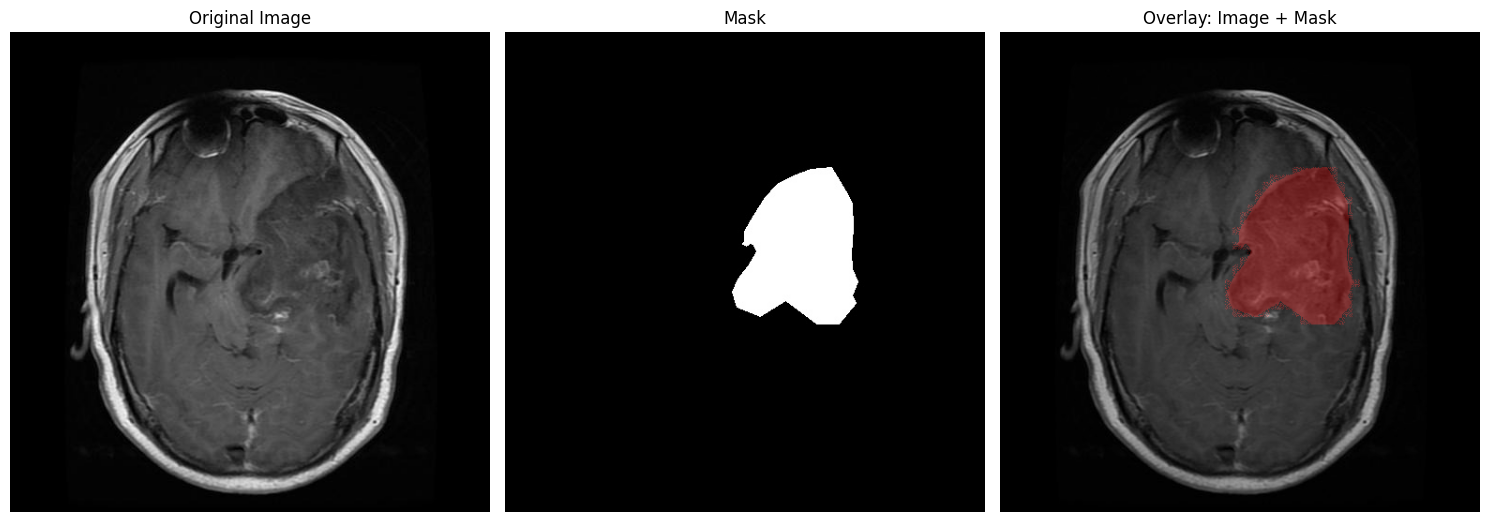

In [46]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(train_image_np)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Mask')
plt.imshow(train_mask_np, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Overlay: Image + Mask')
plt.imshow(train_image_np)

colored_mask = np.zeros_like(train_image_np) 
colored_mask[train_mask_np > 0] = [255, 0, 0]

plt.imshow(colored_mask, alpha=0.3) 
plt.axis('off')

plt.tight_layout()
plt.show()

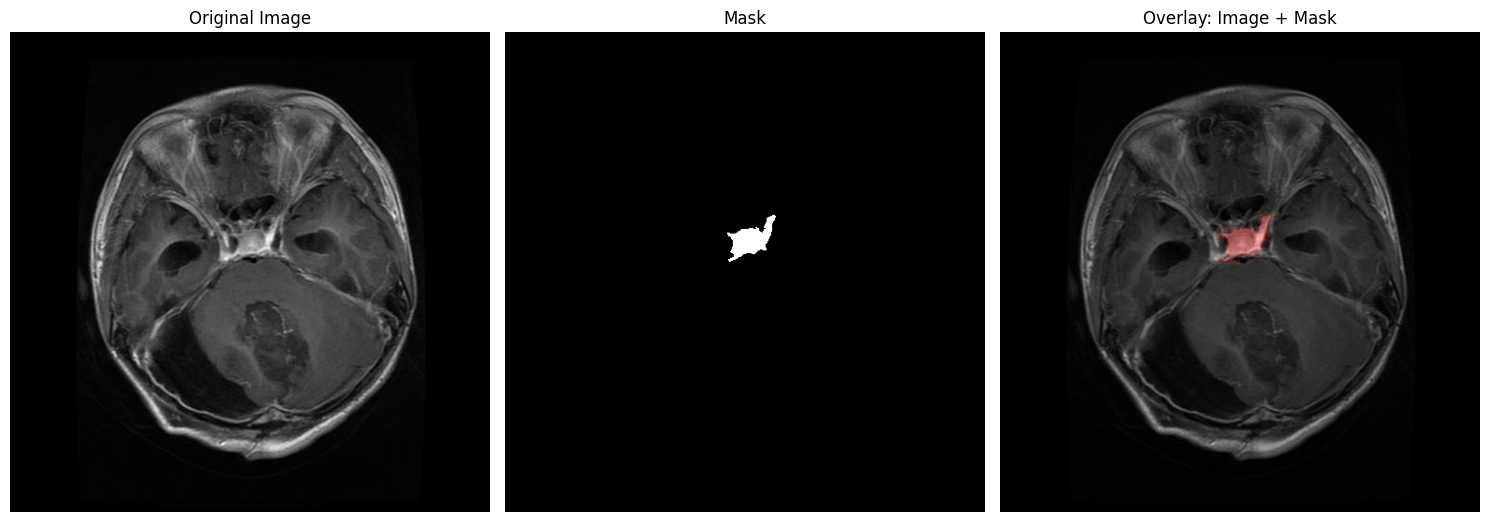

In [47]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(test_image_np)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Mask')
plt.imshow(test_mask_np, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Overlay: Image + Mask')
plt.imshow(test_image_np)

test_colored_mask = np.zeros_like(test_image_np) 
test_colored_mask[test_mask_np > 0] = [255, 0, 0]

plt.imshow(test_colored_mask, alpha=0.3) 
plt.axis('off')

plt.tight_layout()
plt.show()